In [451]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from scipy.stats import f_oneway,chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [229]:
df= pd.read_csv(r"C:\Users\AMRIT\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [452]:
df.isnull().sum()
c=df["Churn"].value_counts()
print(c)
df.drop('customerID', axis=1, inplace=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [447]:
df.shape
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Cluster             0
dtype: int64

In [443]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isna().sum()
X= df.drop(["Churn"], axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

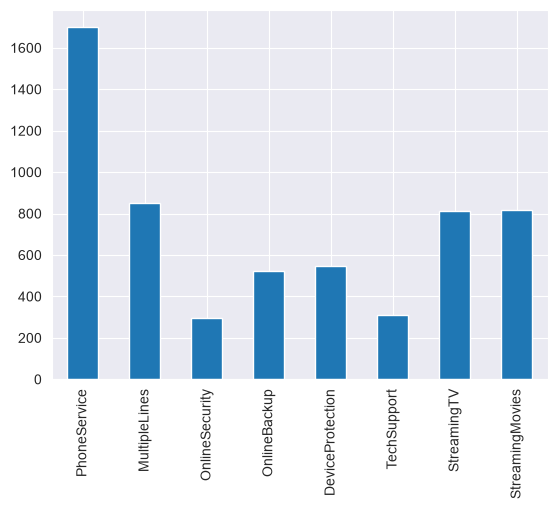

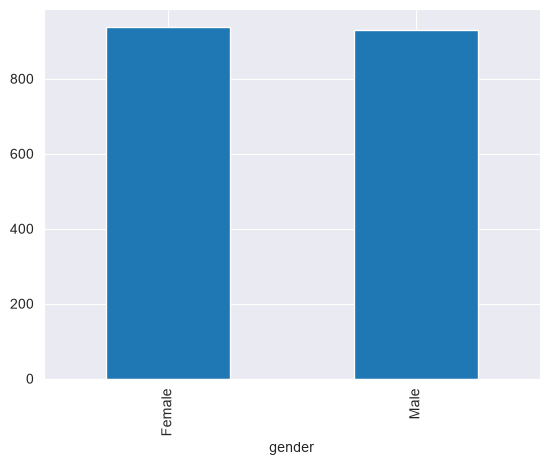

In [448]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

counts = (df[df['Churn'] == 'Yes'][service_cols] == 'Yes').sum()
counts.plot(kind='bar')
plt.show()
gender_wise= df[df['Churn']=='Yes']['gender'].value_counts()
gender_wise.plot(kind='bar')
plt.show()

<Axes: xlabel='Churn'>

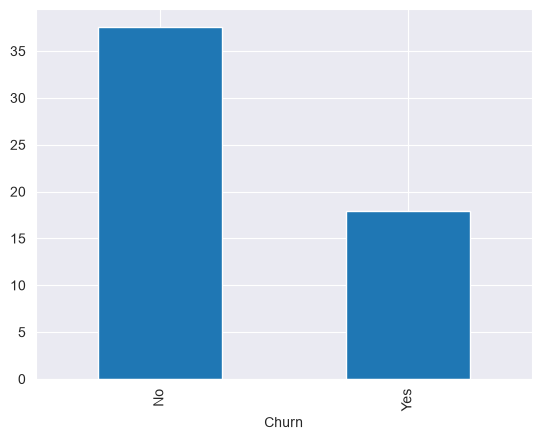

In [449]:
churned= df[df['Churn']=='Yes']
churned
df.groupby('Churn')['tenure'].mean().plot(kind='bar')

In [426]:
tf = ColumnTransformer(
    transformers=[
        ('trf1', OneHotEncoder(handle_unknown='ignore'),
         ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
          'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Partner', 'gender', 'Dependents',
          'PhoneService', 'PaperlessBilling']),
        ('trf2',StandardScaler(),['tenure','MonthlyCharges','TotalCharges'])
    ], remainder='passthrough'
)

X_train_trfd = tf.fit_transform(X_train)
X_test_trfd = tf.transform(X_test)

le = LabelEncoder()

y_train_trfd = le.fit_transform(y_train)
y_test_trfd = le.transform(y_test)

sm = SMOTE(random_state=42)
X_train_trfd_rsm, y_train_trfd_rsm = sm.fit_resample(X_train_trfd, y_train_trfd)


In [450]:
tab= pd.crosstab(df['Contract'], df['Churn'])
chi2,p, dof, expected= chi2_contingency(tab)
print(chi2,p,dof)

f=f_oneway(
    df[df['Contract']=='Month-to-month']['MonthlyCharges'],
    df[df['Contract']=='One year']['MonthlyCharges'],
    df[df['Contract']=='Two year']['MonthlyCharges']
)
print(f)

tukey = pairwise_tukeyhsd(
    endog=df['MonthlyCharges'],
    groups=df['Contract'],
    alpha=0.05
)

print(tukey)

1184.5965720837926 5.863038300673391e-258 2
F_onewayResult(statistic=np.float64(20.828045474730267), pvalue=np.float64(9.575270975922414e-10))
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
    group1      group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
Month-to-month One year  -1.3499 0.3056 -3.5029  0.8032  False
Month-to-month Two year  -5.6281    0.0 -7.6764 -3.5797   True
      One year Two year  -4.2782 0.0002 -6.7838 -1.7726   True
--------------------------------------------------------------


In [433]:
from sklearn.metrics import ConfusionMatrixDisplay

nest= [20,30,50,80,100,120,150,200]
mf= [0.2,0.4,0.5,0.8,1]
msm= [0.2,0.5,0.8,1]
param={
    'n_estimators':nest,
    'max_features':mf,
    'max_samples':msm,
}
class model:
    def __init__(self):
        self.model = None
        self.accuracy = 0
        self.confusion_matrix = None
        self.cv=None
        self.rf_grid=None
        self.xgb_grid=None
        self.disp1 = None
        self.disp2 = None
        self.disp3=None
    def lgr(self):
        lg= LogisticRegression()
        lg.fit(X_train_trfd_rsm, y_train_trfd_rsm)
        y_pred= lg.predict(X_test_trfd)
        self.accuracy = accuracy_score(y_test_trfd, y_pred)
        self.confusion_matrix = confusion_matrix(y_test_trfd, y_pred)
        self.cv= cross_val_score(estimator=lg, X=X_train_trfd_rsm, y=y_train_trfd_rsm, cv=10, n_jobs=-1,scoring='accuracy').mean()
        print("Accuracy:",self.accuracy)
        print("Confusion Matrix:",self.confusion_matrix)
        print("CV:",self.cv)
        self.disp1 = ConfusionMatrixDisplay(confusion_matrix=self.confusion_matrix)
        self.disp1.plot(cmap='Blues')
        plt.show()
    def rf(self):
        rf= RandomForestClassifier()
        rf.fit(X_train_trfd_rsm, y_train_trfd_rsm)
        y_pred= rf.predict(X_test_trfd)
        self.accuracy = accuracy_score(y_test_trfd, y_pred)
        self.confusion_matrix = confusion_matrix(y_test_trfd, y_pred)
        self.rf_grid = GridSearchCV(estimator=rf,
                               param_grid=param,
                               cv=5,
                               n_jobs=-1,
                               scoring='accuracy')
        self.rf_grid.fit(X_train_trfd_rsm, y_train_trfd_rsm)
        print("Accuracy:",self.accuracy)
        print("Confusion Matrix:",self.confusion_matrix)
        print("CV:",self.rf_grid.best_score_)
        self.disp2 = ConfusionMatrixDisplay(confusion_matrix=self.confusion_matrix)

        self.disp2.plot(cmap='Blues')
        plt.show()
    def xgb(self):
        xgb= XGBClassifier()
        xgb.fit(X_train_trfd_rsm, y_train_trfd_rsm)
        y_pred= xgb.predict(X_test_trfd)
        self.accuracy = accuracy_score(y_test_trfd, y_pred)
        self.confusion_matrix = confusion_matrix(y_test_trfd, y_pred)
        self.xgb_grid = GridSearchCV(estimator=xgb,
                               param_grid={'n_estimators':nest},
                               cv=5,
                               n_jobs=-1,
                               scoring='accuracy')
        self.xgb_grid.fit(X_train_trfd_rsm, y_train_trfd_rsm)
        print("Accuracy:",self.accuracy)
        print("Confusion Matrix:",self.confusion_matrix)
        print("CV:",self.xgb_grid.best_score_)
        self.disp3 = ConfusionMatrixDisplay(confusion_matrix=self.confusion_matrix)

        self.disp3.plot(cmap='Blues')
        plt.show()

trial= model()

Accuracy: 0.7572746628814763
Confusion Matrix: [[755 281]
 [ 61 312]]
CV: 0.7727172890781533


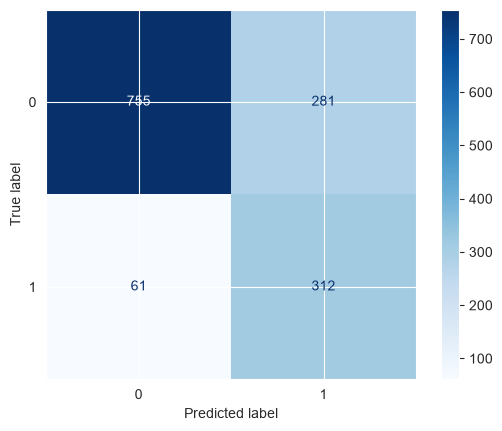

Accuracy: 0.7863733144073811
Confusion Matrix: [[894 142]
 [159 214]]
CV: 0.8556165623130025


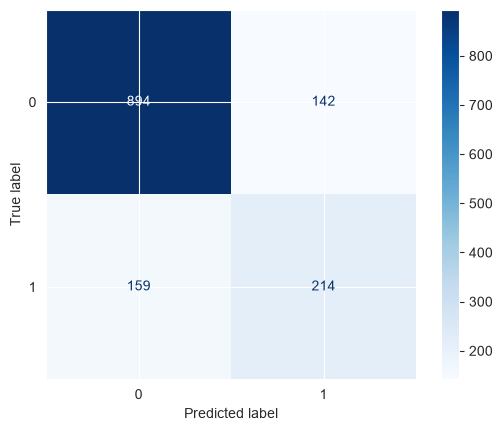

Accuracy: 0.7885024840312278
Confusion Matrix: [[891 145]
 [153 220]]
CV: 0.8402741655355606


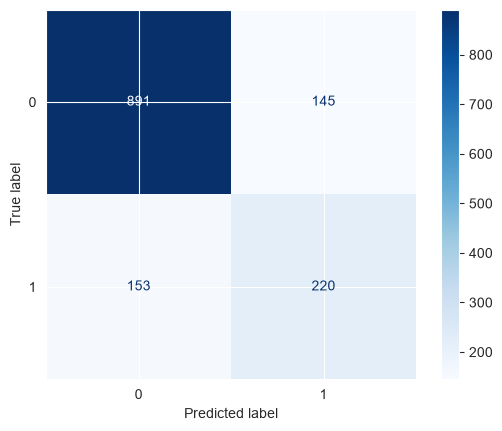

In [434]:
trial.lgr()
trial.rf()
trial.xgb()